# Model implementation

Information Geometry Soft Clustering for Sport Analytics

Joaquin Garay

In [1]:
from pathlib import Path
import sys

# add "<repo>/src" to module search path
repo_root = Path.cwd().parent if Path.cwd().name == "experiment" else Path.cwd()
sys.path.insert(0, str(repo_root / "src"))

In [2]:
%load_ext autoreload
%autoreload 2

import os
import time
import tqdm
import numpy as np
import pandas as pd

import soccer_pattern_recognition as sc
import soccer_pattern_recognition.utils.visualization as vis

from sklearn.neighbors import LocalOutlierFactor
import matplotlib.pyplot as plt
import socceraction.spadl as spadl


### Data Preparation

Concatenate actions of all games in one DataFrame.

In [3]:
datafolder = "../data"
fifa2018h5 = os.path.join(datafolder, "spadl-fifa2018.h5")
games = pd.read_hdf(fifa2018h5, key="games")
with pd.HDFStore(fifa2018h5) as store:
    actions = []  #list of DataFrames
    for game in tqdm.tqdm(games.itertuples()):
        game_action = store[f"actions/game_{game.game_id}"]
        game_action = spadl.play_left_to_right(game_action, game.home_team_id)
        game_action["is_home"] = game_action["team_id"] == game.home_team_id
        actions.append(game_action)
    actions = pd.concat(actions)
    actions.drop("original_event_id", axis=1, inplace=True)
    actions = pd.merge(actions, spadl.config.actiontypes_df(), how="left")

64it [00:00, 176.69it/s]


In [4]:
def consolidate(actions):
    #actions.fillna(0, inplace=True)

    #Consolidate corner_short and corner_crossed
    corner_idx = actions.type_name.str.contains("corner")
    actions["type_name"] = actions["type_name"].mask(corner_idx, "corner")

    #Consolidate freekick_short, freekick_crossed, and shot_freekick
    freekick_idx = actions.type_name.str.contains("freekick")
    actions["type_name"] = actions["type_name"].mask(freekick_idx, "freekick")

    #Consolidate keeper_claim, keeper_punch, keeper_save, keeper_pick_up
    keeper_idx = actions.type_name.str.contains("keeper")
    actions["type_name"] = actions["type_name"].mask(keeper_idx, "keeper_action")

    actions["start_x"] = actions["start_x"].mask(actions.type_name == "shot_penalty", 94.5)
    actions["start_y"] = actions["start_y"].mask(actions.type_name == "shot_penalty", 34)

    return actions


actions = consolidate(actions)

In [5]:
#Actions of Team France matches.
len(actions[actions["team_id"] == 771])

6829

In [6]:
actions.groupby("type_name").size()

type_name
bad_touch         1547
clearance         2074
corner             558
cross             1305
dribble          52731
foul              1876
freekick          1272
goalkick           677
interception      1681
keeper_action      584
pass             56438
shot              1556
shot_penalty        68
tackle            1830
take_on           2109
throw_in          2178
dtype: int64

As suggested in SoccerMix, add noise on the starting and ending locations, but only on those actions that we can visually note a predefined pattern.
* *Add noise in both start and end locations*:
    * Cross
    * Shot
    * Dribble
    * Pass
    * Keeper_action
* *Only on start locations*:
    * Clearance
    * Goal kick
* *Only on end locations*:
    * Throw_in
    * Corner
    * Freekick
    * Shot_penalty

In [7]:
def add_noise(actions):
    # Start locations
    start_list = ["cross", "shot", "dribble", "pass", "keeper_action", "clearance", "goalkick"]
    mask = actions["type_name"].isin(start_list)
    noise = np.random.normal(0, 0.5, size=actions.loc[mask, ["start_x", "start_y"]].shape)
    actions.loc[mask, ["start_x", "start_y"]] += noise

    # End locations
    end_list = ["cross", "shot", "dribble", "pass", "keeper_action", "throw_in", "corner", "freekick", "shot_penalty"]
    mask = actions["type_name"].isin(end_list)
    noise = np.random.normal(0, 0.5, size=actions.loc[mask, ["end_x", "end_y"]].shape)
    actions.loc[mask, ["end_x", "end_y"]] += noise

    return actions


actions = add_noise(actions)

In [8]:
# # display event locations with noise
# corrected_actions = ["cross", "shot", "keeper_action", "clearance", "goalkick","corner", "freekick", "shot_penalty"]
# for actiontype in corrected_actions:
#     actions[actions.type_name == actiontype].plot.scatter(
#         x="start_x",
#         y="start_y",
#         title = f"Start Location: {actiontype}",
#         figsize = (6,4)
#     )
#     plt.show()
#     actions[actions.type_name == actiontype].plot.scatter(
#         x="end_x",
#         y="end_y",
#         title = f"End Location: {actiontype}",
#         figsize = (6,4)
#     )
#     plt.show()

In [9]:
def remove_outliers(actions, verbose=False):
    X = actions[["start_x","start_y","end_x","end_y"]].to_numpy(dtype=float)
    inliers = LocalOutlierFactor(contamination="auto").fit_predict(X)
    if verbose:
        print(f"Remove {(inliers==-1).sum()} out of {X.shape[0]} datapoints.")
    return actions[inliers==1]

actions = remove_outliers(actions,True)

Remove 558 out of 128484 datapoints.


### Features

Compute the angle of the direction of the action with respect with the x-axis (pitch's length) a
$$\tan \theta = \frac{y_{end} - y_{start}}{x_{end} - x_{start}}$$

In [10]:
actions["angle"] = np.arctan2(actions.end_y - actions.start_y, actions.end_x - actions.start_x)
actions["cos_angle"] = np.cos(actions["angle"])
actions["sin_angle"] = np.sin(actions["angle"])
actions[["angle", "cos_angle", "sin_angle"]].describe()

,angle,cos_angle,sin_angle
count,127926.000000,127926.000000,127926.000000
mean,-0.011651,0.277681,-0.005219
std,1.499902,0.680300,0.678281
min,-3.141556,-1.000000,-1.000000
25%,-1.097870,-0.266450,-0.661500
50%,0.000000,0.471650,0.000000
75%,1.060442,0.927115,0.647469
max,3.141548,1.000000,1.000000


### First run

Let's run a first toy implementation using throw-ins of team France.

In [11]:
mask = (actions["type_name"]=="dribble") & (actions["team_id"]==771)
loc_data = actions[mask][["start_x", "start_y"]]
dir_data = actions[mask][["cos_angle", "sin_angle"]]

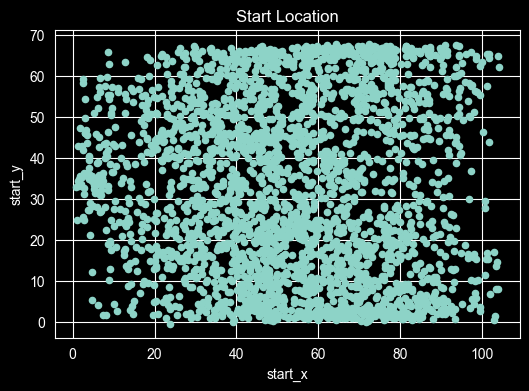

In [12]:
loc_data.plot.scatter(
        x="start_x",
        y="start_y",
        title = f"Start Location",
        figsize = (6,4)
    )
plt.show()

In [13]:
# Gaussian clusters
k_gauss = 4
all_results = []

for init in ["k-means++", "k-means", "random", "random_from_data"]:
    times = {}
    results = {}
    models = {}

    for case in ["classic", "bregman"]:
        loc_model = sc.MixtureModel(
            [sc.MultivariateGaussian() for _ in range(k_gauss)],
            init=init
        )
        start = time.time()
        results[case] = loc_model.fit(loc_data, verbose=False, m_step_case=case)
        times[case] = time.time() - start
        models[case] = loc_model

        all_results.append({
            "initialization": init,
            "case": case,
           # "log_likelihood": round(sc.bic_score_mixture(loc_data, loc_model),4),
            "time_sec": times[case],
           # "ch_score": round(sc.kl_ch_score(loc_data, models[case]),6)
        })

loc_results = pd.DataFrame(all_results)
loc_results

,initialization,case,time_sec
0,k-means++,classic,0.458048
1,k-means++,bregman,0.143193
2,k-means,classic,0.400457
3,k-means,bregman,0.284957
4,random,classic,0.125121
5,random,bregman,0.129263
6,random_from_data,classic,0.113060
7,random_from_data,bregman,0.151697


In [14]:
for case in ["classic","bregman"]:
    print(f"{models[case]}\n")

MixtureModel(n_components=4)
  ├─ (0) w=0.367  MultivariateGaussian(d=2, mean=[53.65  17.046], cov=[[481.182 -19.225], [-19.225  68.06 ]])
  ├─ (1) w=0.411  MultivariateGaussian(d=2, mean=[48.817 47.065], cov=[[580.425  57.526], [ 57.526 103.497]])
  ├─ (2) w=0.100  MultivariateGaussian(d=2, mean=[61.746 65.217], cov=[[354.492   5.111], [5.111 1.701]])
  └─ (3) w=0.122  MultivariateGaussian(d=2, mean=[61.893  2.701], cov=[[323.192  -0.531], [-0.531  1.662]])

MixtureModel(n_components=4)
  ├─ (0) w=0.367  MultivariateGaussian(d=2, mean=[53.65  17.046], cov=[[481.182 -19.225], [-19.225  68.06 ]])
  ├─ (1) w=0.411  MultivariateGaussian(d=2, mean=[48.817 47.065], cov=[[580.425  57.526], [ 57.526 103.497]])
  ├─ (2) w=0.100  MultivariateGaussian(d=2, mean=[61.746 65.217], cov=[[354.492   5.111], [5.111 1.701]])
  └─ (3) w=0.122  MultivariateGaussian(d=2, mean=[61.893  2.701], cov=[[323.192  -0.531], [-0.531  1.662]])



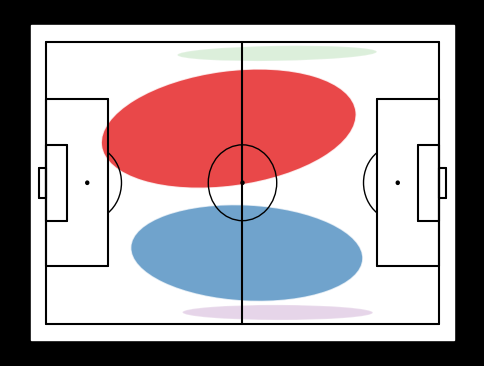

In [15]:
vis.show_location_model(models["classic"])

In [16]:
# Von Mises clusters
k_vm = 3
all_results_vm = []


for init in ["k-means", "random", "random_from_data","k-means++"]:
    times = {}
    results = {}
    models = {}

    for case in ["classic", "bregman"]:
        dir_model = sc.MixtureModel(
            [sc.VonMises() for _ in range(k_vm)],
            init=init
        )
        start = time.time()
        results[case] = dir_model.fit(dir_data, verbose=False, m_step_case=case)
        times[case] = time.time() - start
        models[case] = dir_model

        all_results_vm.append({
            "initialization": init,
            "case": case,
           # "log_likelihood": round(sc.bic_score_mixture(dir_data, dir_model),4),
            "time_sec": times[case],
            #"ch_score": round(sc.kl_ch_score(dir_data, models[case]), 6),
        })

dir_results = pd.DataFrame(all_results_vm)
dir_results


,initialization,case,time_sec
0,k-means,classic,0.071989
1,k-means,bregman,0.044847
2,random,classic,0.023992
3,random,bregman,0.009087
4,random_from_data,classic,0.022554
5,random_from_data,bregman,0.008650
6,k-means++,classic,0.021022
7,k-means++,bregman,0.009204


In [17]:
for case in ["classic","bregman"]:
    print(f"{models[case]}\n")

MixtureModel(n_components=3)
  ├─ (0) w=0.331  VonMises(loc=1.2 deg, kappa=0.502)
  ├─ (1) w=0.329  VonMises(loc=2.2 deg, kappa=0.504)
  └─ (2) w=0.340  VonMises(loc=2.0 deg, kappa=0.515)

MixtureModel(n_components=3)
  ├─ (0) w=0.331  VonMises(loc=1.2 deg, kappa=0.502)
  ├─ (1) w=0.329  VonMises(loc=2.2 deg, kappa=0.504)
  └─ (2) w=0.340  VonMises(loc=2.0 deg, kappa=0.515)



### Two layer scheme

Running a Gaussian mixture model to get location clusters. Then, for each one of the location clusters, run a von Mises mixture model using again all dataset, but for this second step, each datapoint is weighted by the posteriors of the location mixture model.

In [18]:
K_loc = 10
K_dir = [3 for _ in range(K_loc)]
init = "k-means++"
loc_mixture = sc.MixtureModel(
            [sc.MultivariateGaussian() for _ in range(K_loc)],
            init=init
        )
dir_mixtures = [ sc.MixtureModel(
                    [sc.VonMises() for _ in range(K_dir[j])],
                    init=init
                    )
                 for j in range(K_loc)]

model = sc.TwoLayerMoM(loc_mixture,
                       dir_mixtures)

model.fit(loc_data, dir_data)

514

In [19]:
#model.bic_score(loc_data, dir_data)

In [20]:
#model.completed_bic_score(loc_data, dir_data)

In [21]:
loc_data.shape

(2824, 2)

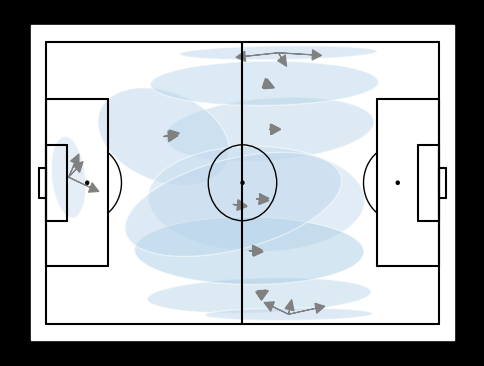

In [22]:
model.plot()

60065.219720742294
61200.160208648376


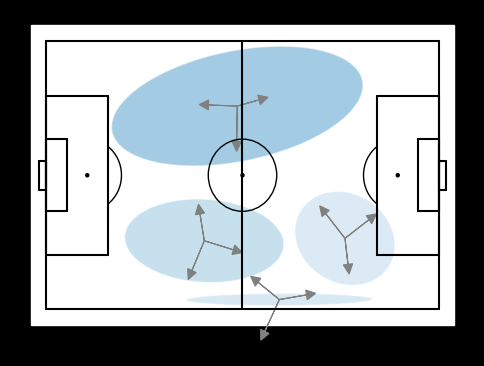

In [23]:
from time import time
K_loc = 4
K_dir = [3 for _ in range(K_loc)]
init = "k-means++"
loc_mixture = sc.MixtureModel(
    [sc.MultivariateGaussian() for _ in range(K_loc)],
    init=init
)
dir_mixtures = [sc.MixtureModel(
    [sc.VonMises() for _ in range(K_dir[j])],
    init="k-means"
)
    for j in range(K_loc)]

model = sc.TwoLayerMoM(loc_mixture,
                       dir_mixtures)

model.fit(loc_data, dir_data, c_step_bool=True)
print(model.bic_score(loc_data, dir_data))
print(model.completed_bic_score(loc_data, dir_data))
model.plot()

### One-shot Scheme



In [24]:
oneshot_model = sc.OneShotScheme(n_clusters=30, alpha=1, beta=1, init="k-means++")
oneshot_model.fit(loc_data, dir_data, c_step=False)
oneshot_model.bic_score(loc_data, dir_data)


AttributeError: module 'soccer_pattern_recognition' has no attribute 'OneShotScheme'

In [ ]:
oneshot_model.completed_bic_score(loc_data, dir_data)

In [ ]:
oneshot_model.plot()

In [ ]:
oneshot_model = sc.OneShotScheme(n_clusters=30, alpha=1, beta=1, init="k-means++")
oneshot_model.fit(loc_data, dir_data, c_step=True)
oneshot_model.bic_score(loc_data, dir_data)

In [ ]:
oneshot_model.completed_bic_score(loc_data, dir_data)

In [ ]:
oneshot_model.plot()